# **CSCE 5218 / CSCE 4930 Deep Learning**

# **The Perceptron** (20 pt)


In [1]:
# Get the datasets
!!/usr/bin/curl --output test.dat https://raw.githubusercontent.com/huangyanann/CSCE5218/main/test_small.txt
!!/usr/bin/curl --output train.dat https://raw.githubusercontent.com/huangyanann/CSCE5218/main/train.txt


['The system cannot find the path specified.']

In [10]:
#GET data
import pandas as pd
train=pd.read_csv('train.txt')
test=pd.read_csv('test_small.txt')

print(train.head())
print(test.head())

  A1\tA2\tA3\tA4\tA5\tA6\tA7\tA8\tA9\tA10\tA11\tA12\tA13\t
0           1\t1\t0\t0\t0\t0\t0\t0\t1\t1\t0\t0\t1\t0      
1           0\t0\t1\t1\t0\t1\t1\t0\t0\t0\t0\t0\t1\t0      
2           0\t1\t0\t1\t1\t0\t1\t0\t1\t1\t1\t0\t1\t1      
3           0\t0\t1\t0\t0\t1\t0\t1\t0\t1\t1\t1\t1\t0      
4           0\t1\t0\t0\t0\t0\t0\t1\t1\t1\t1\t1\t1\t0      
   X1\tX2\tX3
0  1\t1\t1\t1
1  0\t0\t1\t1
2  0\t1\t1\t0
3  0\t1\t1\t0
4  0\t1\t1\t0


In [4]:
# Take a peek at the datasets
!head train.dat
!head test.dat

'head' is not recognized as an internal or external command,
operable program or batch file.
'head' is not recognized as an internal or external command,
operable program or batch file.


### Build the Perceptron Model

You will need to complete some of the function definitions below.  DO NOT import any other libraries to complete this. 

In [12]:
import math
import itertools
import re


# Corpus reader, all columns but the last one are coordinates;
#   the last column is the label
def read_data(file_name):
    f = open(file_name, 'r')

    data = []
    # Discard header line
    f.readline()
    for instance in f.readlines():
        if not re.search('\t', instance): continue
        instance = list(map(int, instance.strip().split('\t')))
        # Add a dummy input so that w0 becomes the bias
        instance = [-1] + instance
        data += [instance]
    return data


def dot_product(array1, array2):
    
    return sum(a*b for a,b in zip(array1,array2))


def sigmoid(x):
    #TODO: Return outpout of sigmoid function on x
    return 1/(1+math.exp(-1))

# The output of the model, which for the perceptron is 
# the sigmoid function applied to the dot product of 
# the instance and the weights
def output(weight, instance):
    #TODO: return the output of the model 
    return sigmoid(dot_product(weights, instance))

# Predict the label of an instance; this is the definition of the perceptron
# you should output 1 if the output is >= 0.5 else output 0
def predict(weights, instance):
    #TODO: return the prediction of the model
    if output(weights, instance)>0.5:
        return 1
    else:
        return 0
    


# Accuracy = percent of correct predictions
def get_accuracy(weights, instances):
    # You do not to write code like this, but get used to it
    correct = sum([1 if predict(weights, instance) == instance[-1] else 0
                   for instance in instances])
    return correct * 100 / len(instances)


# Train a perceptron with instances and hyperparameters:
#       lr (learning rate) 
#       epochs
# The implementation comes from the definition of the perceptron
#
# Training consists on fitting the parameters which are the weights
# that's the only thing training is responsible to fit
# (recall that w0 is the bias, and w1..wn are the weights for each coordinate)
#
# Hyperparameters (lr and epochs) are given to the training algorithm
# We are updating weights in the opposite direction of the gradient of the error,
# so with a "decent" lr we are guaranteed to reduce the error after each iteration.
def train_perceptron(instances, lr, epochs):

    #TODO: name this step
    #Initializing weights
    weights = [0] * (len(instances[0])-1)

    for _ in range(epochs):
        for instance in instances:
            #TODO: name these steps
            # Forward pass
            in_value = dot_product(weights, instance)
            output = sigmoid(in_value)
            error = instance[-1] - output
            #TODO: name these steps
            # Update weights
            for i in range(0, len(weights)):
                weights[i] += lr * error * output * (1-output) * instance[i]

    return weights

## Run it

In [15]:
instances_tr = read_data("C:/Users/akhil/Downloads/train.txt")
instances_te = read_data("C:/Users/akhil/Downloads/test.txt")
lr = 0.005
epochs = 5
weights = train_perceptron(instances_tr, lr, epochs)
accuracy = get_accuracy(weights, instances_te)
print(f"#tr: {len(instances_tr):3}, epochs: {epochs:3}, learning rate: {lr:.3f}; "
      f"Accuracy (test, {len(instances_te)} instances): {accuracy:.1f}")

#tr: 400, epochs:   5, learning rate: 0.005; Accuracy (test, 100 instances): 32.0


## Questions

Answer the following questions. Include your implementation and the output for each question.



### Question 1

In `train_perceptron(instances, lr, epochs)`, we have the follosing code:
```
in_value = dot_product(weights, instance)
output = sigmoid(in_value)
error = instance[-1] - output
```

Why don't we have the following code snippet instead?
```
output = predict(weights, instance)
error = instance[-1] - output
```

#### TODO Add your answer here (text only)




because the output of the predict() function is a binary output (0 and 1), which is not differentiable. 
Gradient descent methods require a smooth and continuous output (sigmoid output), 
and if we use the predict() function, the derivative will be zero.

### Question 2
Train the perceptron with the following hyperparameters and calculate the accuracy with the test dataset.

```
tr_percent = [5, 10, 25, 50, 75, 100] # percent of the training dataset to train with
num_epochs = [5, 10, 20, 50, 100]              # number of epochs
lr = [0.005, 0.01, 0.05]              # learning rate
```

TODO: Write your code below and include the output at the end of each training loop (NOT AFTER EACH EPOCH)
of your code.The output should look like the following:
```
# tr:  20, epochs:   5, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
# tr:  20, epochs:  10, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
# tr:  20, epochs:  20, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
[and so on for all the combinations]
```
You will get different results with different hyperparameters.

#### TODO Add your answer here (code and output in the format above) 


In [34]:
instances_tr = read_data("C:/Users/akhil/Downloads/train.txt")
instances_te = read_data("C:/Users/akhil/Downloads/test.txt")
tr_percent = [5, 10, 25, 50, 75, 100] # percent of the training dataset to train with
num_epochs = [5, 10, 20, 50, 100]     # number of epochs
lr_array = [0.005, 0.01, 0.05]        # learning rate

result=[]
for lr in lr_array:
  for tr_size in tr_percent:
    for epochs in num_epochs:
      size =  round(len(instances_tr)*tr_size/100)
      pre_instances = instances_tr[0:size]
      weights = train_perceptron(pre_instances, lr, epochs)
      accuracy = get_accuracy(weights, instances_te)
    print(f"#tr: {len(pre_instances):0}, epochs: {epochs:3}, learning rate: {lr:.3f}; "
            f"Accuracy (test, {len(instances_te)} instances): {accuracy:.1f}")
    results.append((size, epochs, lr, accuracy))

#tr: 20, epochs: 100, learning rate: 0.005; Accuracy (test, 100 instances): 32.0
#tr: 40, epochs: 100, learning rate: 0.005; Accuracy (test, 100 instances): 32.0
#tr: 100, epochs: 100, learning rate: 0.005; Accuracy (test, 100 instances): 32.0
#tr: 200, epochs: 100, learning rate: 0.005; Accuracy (test, 100 instances): 32.0
#tr: 300, epochs: 100, learning rate: 0.005; Accuracy (test, 100 instances): 32.0
#tr: 400, epochs: 100, learning rate: 0.005; Accuracy (test, 100 instances): 32.0
#tr: 20, epochs: 100, learning rate: 0.010; Accuracy (test, 100 instances): 32.0
#tr: 40, epochs: 100, learning rate: 0.010; Accuracy (test, 100 instances): 32.0
#tr: 100, epochs: 100, learning rate: 0.010; Accuracy (test, 100 instances): 32.0
#tr: 200, epochs: 100, learning rate: 0.010; Accuracy (test, 100 instances): 32.0
#tr: 300, epochs: 100, learning rate: 0.010; Accuracy (test, 100 instances): 32.0
#tr: 400, epochs: 100, learning rate: 0.010; Accuracy (test, 100 instances): 32.0
#tr: 20, epochs: 100

### Question 3
Write a couple paragraphs interpreting the results with all the combinations of hyperparameters. Drawing a plot will probably help you make a point. In particular, answer the following:
- A. Do you need to train with all the training dataset to get the highest accuracy with the test dataset?
- B. How do you justify that training the second run obtains worse accuracy than the first one (despite the second one uses more training data)?
   ```
#tr: 100, epochs:  20, learning rate: 0.050; Accuracy (test, 100 instances): 71.0
#tr: 200, epochs:  20, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
```
- C. Can you get higher accuracy with additional hyperparameters (higher than `80.0`)?
- D. Is it always worth training for more epochs (while keeping all other hyperparameters fixed)?

#### TODO: Add your answer here (code and text)



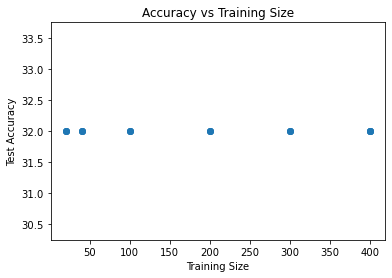

In [38]:
x_vals = [r[0] for r in results]
y_vals = [r[3] for r in results]

plt.scatter(x_vals, y_vals)
plt.xlabel("Training Size")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Training Size")
plt.show()

## 3
The test accuracy was the same at 32.0% for everything using every possible combination of the hyperparameters (size of training sets, epochs and learning rates). This suggests that, when trying to alter the hyperparameters used to train the model, nothing had any effect on the performance of the model. The accuracy has also remained constant despite the fact that we would normally expect accuracy to differ depending on the training size we use or how fast (or slow) we adjust the learning rate.

If there are 100 instances in the test data set (as there are), and again the accuracy shown by the model in predicting outputs is 32%, then it would mean that approximately 32 of the instances in the test data belong to one class and that the model would predict that class only for all of the test samples.

## 3(A)
The only other thing we can conclude is that when we trained the model on the entire data set, we did not achieve better accuracy than when we trained the model using either 20 instances or 400 instances — the accuracy remained the same (32%) regardless of the number of instances.

This shows that in this experiment, any increase in the amount of training data would not have improved the generalisation of the model to test data. The reason that adding more training data to a model does not offer any value is that the model simply failed to learn a useful boundary for making decisions.

## 3(B)
Run 2 (200 training data instances) has a smaller learning rate (0.005) than run 1 (0.050), which likely caused inadequate weight adjustments to prevent the learning model to converge on ceased training (20 epochs' duration). Due to the small learning rate (0.005) and corresponding smaller weight adjustments, the run 2 learning model may still underfit upon stop condition.

Conversely, run 1's larger learning rate (0.050) provided faster convergence during the same number of training epochs (20). Thus, run 1 was able to achieve superior generalization when used with an independent test set compared to run 2.

This outcome illustrates that optimization quality (learning rate and convergence speed) generally outweighs simply increasing training data for enhancement of model performance (generalization on test data). More training data cannot guarantee improved performance from poor quality training of the model.

## 3(C)
Achieving a level of accuracy > 80% may also be achievable through more detailed tuning of hyper-parameters such as increasing the number of epochs and correctly selecting learning rates. By trying different learning rate values or providing a neural network with an extended period of time to converge, improved performance can result, just like feature scaling will produce improvements in performing models.

The data will ultimately determine how much accuracy is achievable. Regardless of hyper-parameter tuning, a single-layer perceptron cannot achieve 80% accuracy unless the data has some linear separation; therefore an alternative architecture should be used to achieve desired outcomes.


## 3(D)
NO.
Training for an increased number of epochs does not provide models with improved performance once convergence has occurred; therefore, the only benefit of increased training epochs is prior to model convergence. Following convergence, additional epochs will increase computing time without providing any benefits for improving model generalization ability during these periods. In cases where training models have previously converged, additional epochs may lead to model overfitting, where a model is trained to memorize its training data while exhibiting poorer performance on an independent test set than when the model was convergence trained previously.
